<a href="https://colab.research.google.com/github/Avinash01715/ds-ml-projects/blob/main/2.%20Spam%20SMS%20detector/SpamClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Workflow :**

1.   Imports & Setup
2.   Data Cleaning & Preparation
3.   Exploratory Data Analysis (EDA)
4.   Text Preprocessing
5.   Visualizing Text Features
6.   Model Building & Benchmarking
7.   Model Improvement & Ensembles
8.   Final Model Selection & Deployment





# **1. IMPORTS & SETUP**

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('spam_data.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# **2. DATA CLEANING & PREPARATION**

In [14]:
df.shape

(5572, 5)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [16]:
# Drop useless columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
# Rename columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text
3801,ham,No da. I am happy that we sit together na
4936,ham,G wants to know where the fuck you are
346,ham,Dis is yijue. I jus saw ur mail. In case huimi...
1043,ham,Mmm thats better now i got a roast down me! iå...
3893,spam,Dear Dave this is your final notice to collect...


In [18]:
# Encode categorical target labels into numerical format for model training
# 'ham' -> 0, 'spam' -> 1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
# Check for missing values across all columns
df.isnull().sum()

,0
target,0
text,0


In [21]:
# Identify and count exact duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Remove exact duplicates, keeping the first occurrence
df = df.drop_duplicates(keep='first')

print(f"Remaining duplicate rows: {df.duplicated().sum()}")
print(f"Updated dataset shape: {df.shape}")

Number of duplicate rows: 0
Remaining duplicate rows: 0
Updated dataset shape: (5169, 2)


# **3. EXPLORATORY DATA ANALYSIS (EDA)**

In [22]:
df['target'].value_counts()

,count
target,
0,4516
1,653


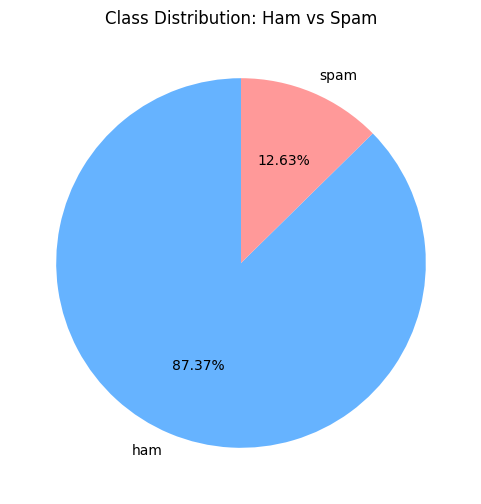

In [23]:
# Visualize the class distribution (Ham vs. Spam)
plt.figure(figsize=(6, 6))
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f%%", startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Class Distribution: Ham vs Spam')
plt.show()

In [24]:
# Note: The dataset is imbalanced.
# This imbalance must be considered during model evaluation (e.g., prioritizing Precision/Recall over simple Accuracy).

In [25]:
# Download necessary NLTK data for text preprocessing
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')

# Initialize the Porter Stemmer
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [26]:
# Create structural features based on text length
# 1. Character count
df['num_characters'] = df['text'].apply(len)

# 2. Word count (using NLTK tokenizer for better accuracy than simple string split)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

# 3. Sentence count
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
# Summary statistics for the newly created structural features
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# Compare structural features for 'ham' messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# Compare structural features for 'spam' messages
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [30]:
# Observation: Spam messages tend to be longer on average

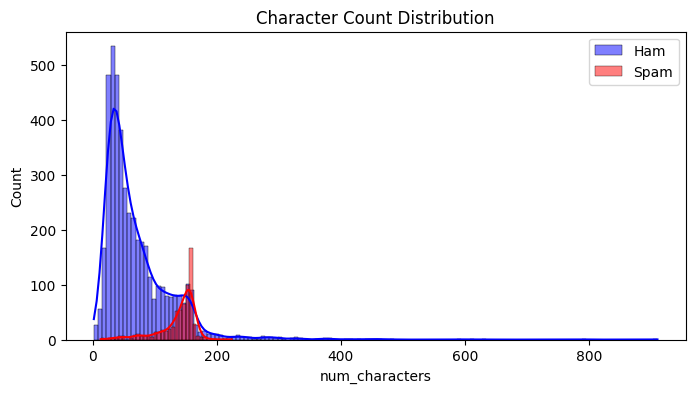

In [60]:
# Distribution of character counts for Ham vs Spam
plt.figure(figsize=(8, 4))
sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Ham', kde=True)
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam', kde=True)
plt.title('Character Count Distribution')
plt.legend()
plt.show()

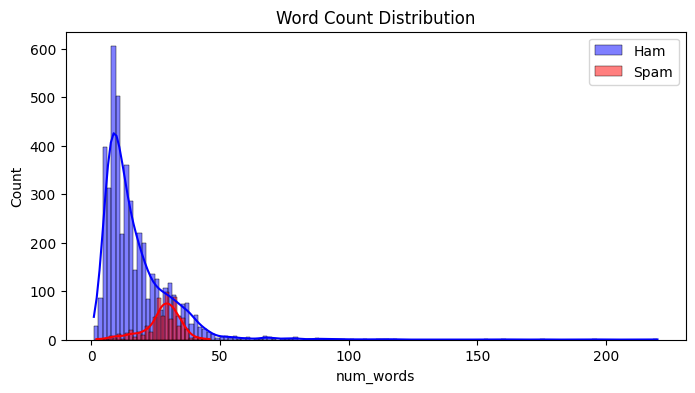

In [61]:
# Distribution of word counts for Ham vs Spam
plt.figure(figsize=(8, 4))
sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Ham', kde=True)
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Spam', kde=True)
plt.title('Word Count Distribution')
plt.legend()
plt.show()

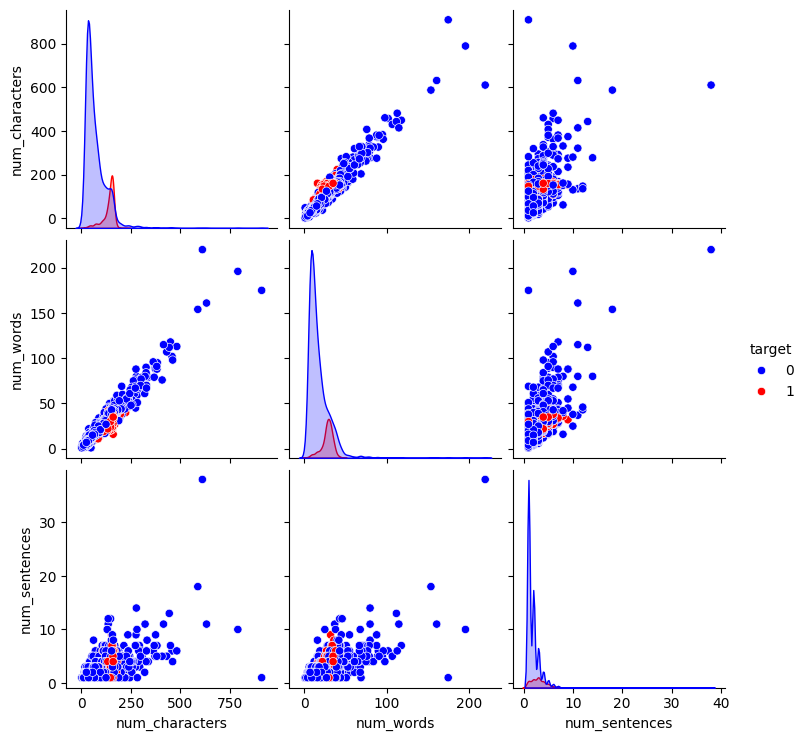

In [62]:
# Pairplot to visualize pairwise relationships between structural features
sns.pairplot(df, hue='target', palette=['blue', 'red'])
plt.show()

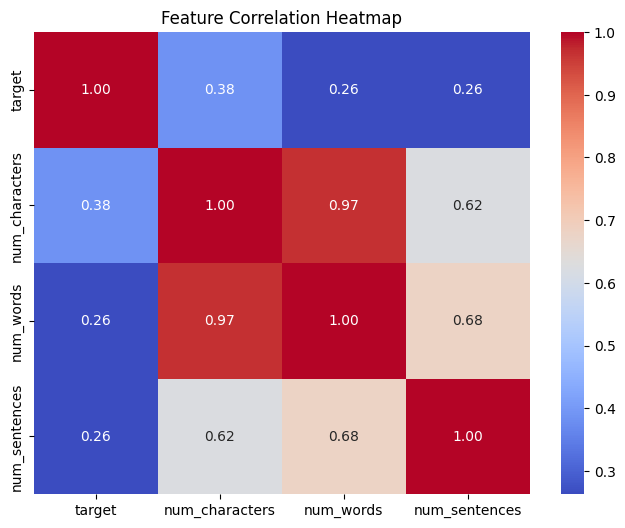

In [63]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# **4. TEXT PREPROCESSING**

In [64]:
# text transformation pipeline:
# 1. Convert to lowercase
# 2. Tokenize into words
# 3. Filter out non-alphanumeric tokens
# 4. Remove stopwords and punctuation
# 5. Apply stemming to reduce words to their root form

def transform_text(text):

    text = text.lower()
    text = nltk.word_tokenize(text)

    # Keep only alphanumeric tokens
    text = [word for word in text if word.isalnum()]

    # Remove stopwords and punctuation
    stop_words = set(stopwords.words('english'))
    text = [word for word in text if word not in stop_words and word not in string.punctuation]

    # Apply stemming
    text = [ps.stem(word) for word in text]

    # Join tokens back into a single string
    return " ".join(text)

In [65]:
sample_text = "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."
print("Original:", sample_text)
print("Processed:", transform_text(sample_text))

Original: I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
Processed: gon na home soon want talk stuff anymor tonight k cri enough today


In [66]:
# Apply the preprocessing function to the entire dataset
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# **5. VISUALIZING TEXT FEATURES**

In [67]:
from wordcloud import WordCloud
from collections import Counter

# Initialize WordCloud object
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

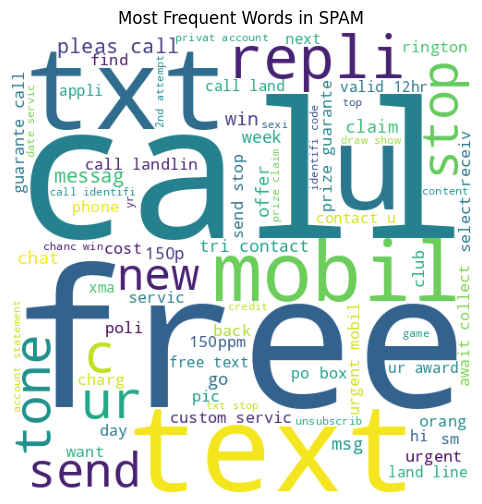

In [68]:
# Generate and plot Word Cloud for SPAM messages
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 6))
plt.imshow(spam_wc)
plt.title('Most Frequent Words in SPAM')
plt.axis('off')
plt.show()

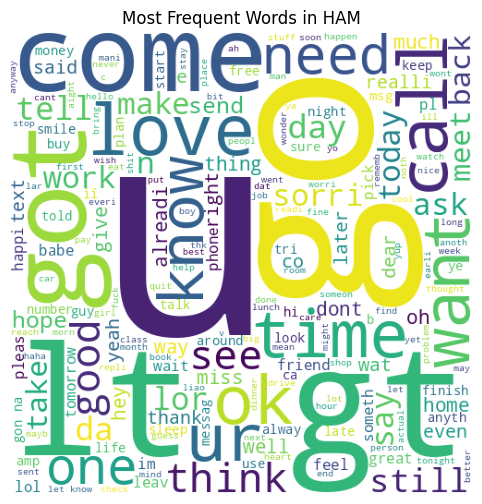

In [69]:
# Generate and plot Word Cloud for HAM messages
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 6))
plt.imshow(ham_wc)
plt.title('Most Frequent Words in HAM')
plt.axis('off')
plt.show()

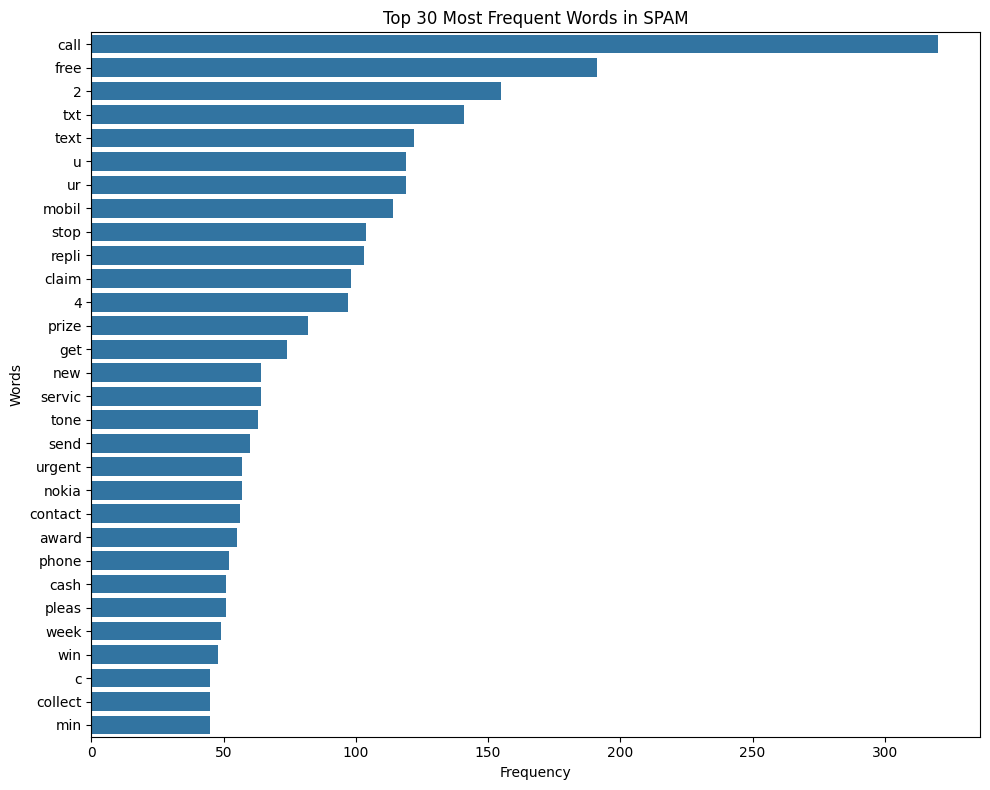

In [70]:
# Extract and plot top 30 most frequent words in SPAM messages
spam_corpus = [word for msg in df[df['target'] == 1]['transformed_text'] for word in msg.split()]
spam_counts = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

plt.figure(figsize=(10, 8))
sns.barplot(data=spam_counts, x='count', y='word')
plt.title('Top 30 Most Frequent Words in SPAM')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

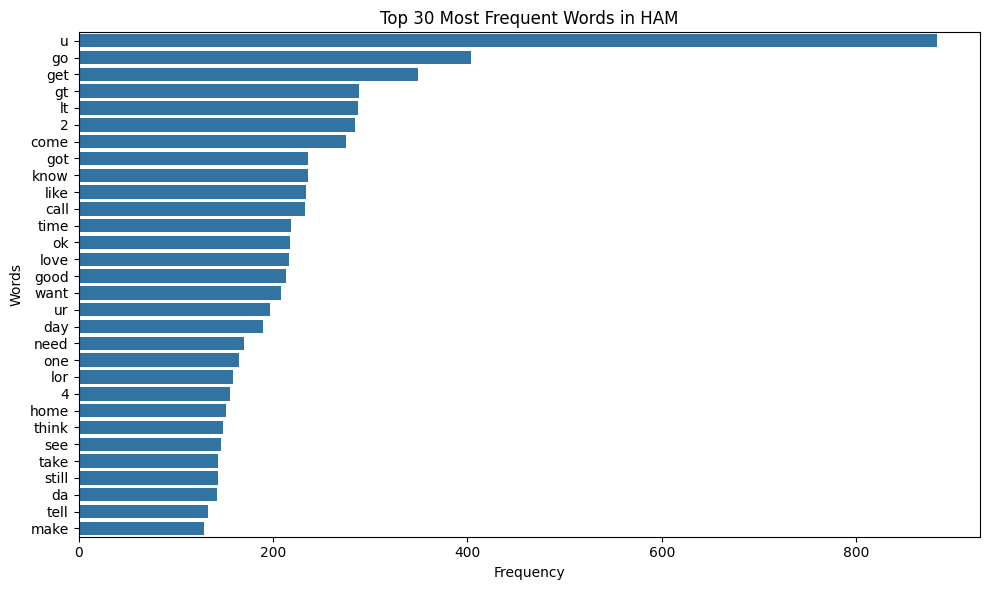

In [73]:
# Extract and plot top 30 most frequent words in HAM messages
ham_corpus = [word for msg in df[df['target'] == 0]['transformed_text'] for word in msg.split()]
ham_counts = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=ham_counts, x='count', y='word')
plt.title('Top 30 Most Frequent Words in HAM')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

# **6. MODEL BUILDING & FEATURE EXTRACTION**

In [74]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Initialize TF-IDF Vectorizer
# Limiting max_features to 3000 to reduce dimensionality and noise
tfidf = TfidfVectorizer(max_features=3000)

# Transform the preprocessed text into a TF-IDF matrix
X = tfidf.fit_transform(df['transformed_text']).toarray()

# Extract the target variable
y = df['target'].values

In [75]:
# Split the dataset into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [76]:
# Evaluate the three variants of the Naive Bayes algorithm
# Naive Bayes is a strong, computationally efficient baseline for text classification
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [77]:
# 1. Gaussian Naive Bayes
# Note: GaussianNB assumes features follow a normal distribution, which is generally
# not ideal for TF-IDF counts (which are non-negative and sparse).
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("--- Gaussian NB ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred1):.4f}")

--- Gaussian NB ---
Accuracy:  0.8733
Precision: 0.5160


In [78]:
# 2. Multinomial Naive Bayes
# Note: MultinomialNB is typically the best fit for word count/TF-IDF features.
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("\n--- Multinomial NB ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred2):.4f}")


--- Multinomial NB ---
Accuracy:  0.9710
Precision: 1.0000


In [79]:
# 3. Bernoulli Naive Bayes
# Note: BernoulliNB is useful for binary/boolean features.
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("\n--- Bernoulli NB ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred3):.4f}")
print(f"Precision: {precision_score(y_test, y_pred3):.4f}")


--- Bernoulli NB ---
Accuracy:  0.9836
Precision: 0.9919


In [80]:
# Import a diverse set of machine learning algorithms for benchmarking
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              BaggingClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from xgboost import XGBClassifier

In [81]:
# Instantiate classifiers with reasonable default hyperparameters
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

# Store classifiers in a dictionary for easy iteration
clfs = {
    'SVC': svc, 'KN': knc, 'NB': mnb, 'DT': dtc, 'LR': lrc,
    'RF': rfc, 'AdaBoost': abc, 'BgC': bc, 'ETC': etc,
    'GBDT': gbdt, 'XGB': xgb
}

In [82]:
# function to train a model and return evaluation metrics
def train_classifier(clf, X_train, y_train, X_test, y_test):

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [83]:
# Train and evaluate all classifiers, storing the results
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    print(f"Algorithm: {name}")
    print(f"Accuracy:  {current_accuracy:.4f}")
    print(f"Precision: {current_precision:.4f}\n")

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

Algorithm: SVC
Accuracy:  0.9758
Precision: 0.9748

Algorithm: KN
Accuracy:  0.9052
Precision: 1.0000

Algorithm: NB
Accuracy:  0.9710
Precision: 1.0000

Algorithm: DT
Accuracy:  0.9294
Precision: 0.8283

Algorithm: LR
Accuracy:  0.9565
Precision: 0.9697

Algorithm: RF
Accuracy:  0.9768
Precision: 0.9750

Algorithm: AdaBoost
Accuracy:  0.9236
Precision: 0.8391

Algorithm: BgC
Accuracy:  0.9594
Precision: 0.8692

Algorithm: ETC
Accuracy:  0.9778
Precision: 0.9675

Algorithm: GBDT
Accuracy:  0.9507
Precision: 0.9307

Algorithm: XGB
Accuracy:  0.9691
Precision: 0.9492



In [84]:
# Compile results into a DataFrame and sort by Precision
# Precision is prioritized for spam detection to minimize False Positives (flagging legitimate messages as spam)
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision', ascending=False)

performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.976789,0.975000
0,SVC,0.975822,0.974790
4,LR,0.956480,0.969697
8,ETC,0.977756,0.967480
10,XGB,0.969052,0.949153
9,GBDT,0.950677,0.930693
7,BgC,0.959381,0.869231
6,AdaBoost,0.923598,0.839080


In [85]:
# Reshape DataFrame for grouped bar plotting
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.976789
3,SVC,Accuracy,0.975822
4,LR,Accuracy,0.956480
5,ETC,Accuracy,0.977756
6,XGB,Accuracy,0.969052
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.959381
9,AdaBoost,Accuracy,0.923598


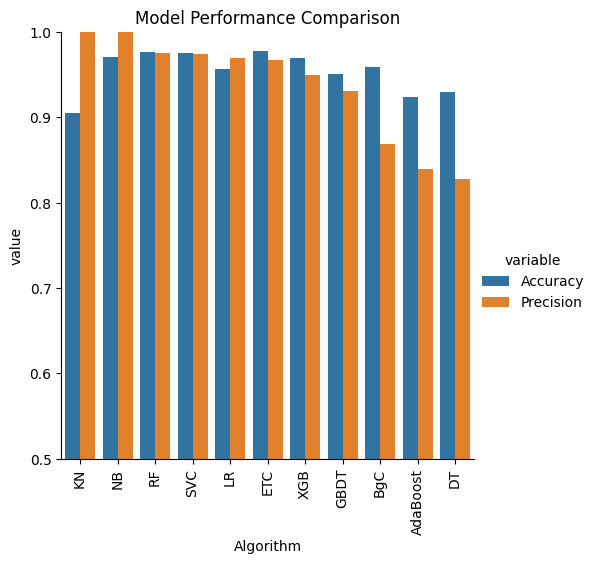

In [86]:
# Plot grouped bar chart: Accuracy vs Precision for all algorithms
sns.catplot(x='Algorithm', y='value', hue='variable', data=performance_df1, kind='bar', height=5)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.title('Model Performance Comparison')
plt.show()

# **7. MODEL IMPROVEMENT & ENSEMBLE METHODS**

In [87]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

In [88]:
# Voting Classifier (Soft Voting)
# Combines probability estimates from base models to predict the final class
voting = VotingClassifier(
    estimators=[('svm', svc), ('nb', mnb), ('et', etc)],
    voting='soft'
)
voting.fit(X_train, y_train)

y_pred_voting = voting.predict(X_test)
print("--- Voting Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_voting):.4f}")


--- Voting Classifier ---
Accuracy:  0.9807
Precision: 0.9836


In [89]:
# Stacking Classifier
# Uses a meta-learner (RandomForest) to combine predictions from base models
estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator
)
stacking.fit(X_train, y_train)

y_pred_stacking = stacking.predict(X_test)
print("\n--- Stacking Classifier ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_stacking):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_stacking):.4f}")


--- Stacking Classifier ---
Accuracy:  0.9787
Precision: 0.9394


# **8. FINAL MODEL SELECTION & DEPLOYMENT**

In [92]:
# Based on the evaluation, MultinomialNB provides an excellent balance of
# high precision, high accuracy, and computational efficiency.

final_model = MultinomialNB()
final_model.fit(X_train, y_train)

# Final validation on the test set
y_pred_final = final_model.predict(X_test)
print("--- Final Model (MultinomialNB) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")

--- Final Model (MultinomialNB) ---
Accuracy:  0.9710
Precision: 1.0000


In [93]:
# Save the vectorizer and the final model using joblib
import joblib

joblib.dump(tfidf, 'vectorizer.joblib')
joblib.dump(final_model, 'model.joblib')

print("Model and Vectorizer successfully saved to disk.")

Model and Vectorizer successfully saved to disk.
